<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1945 | Val: 472 | Test: 90


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 8 (effective batch size ≈ 128, tuned value = 121)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 8 micro-batches per optimizer step (effective batch size ≈ micro_batch x 8).


[ResNet-50] Epoch   1/100 | LR: 2.68e-05 | train loss 1.3792 acc 0.388 | val loss 1.3521 acc 0.392 *


[ResNet-50] Epoch   2/100 | LR: 2.68e-05 | train loss 1.2948 acc 0.389 | val loss 1.1724 acc 0.458 *


[ResNet-50] Epoch   3/100 | LR: 2.68e-05 | train loss 1.1926 acc 0.535 | val loss 1.0537 acc 0.621 *


[ResNet-50] Epoch   4/100 | LR: 2.68e-05 | train loss 1.1199 acc 0.607 | val loss 0.9908 acc 0.653 *


...

[ResNet-50] Epoch  38/100 | LR: 2.68e-06 | train loss 0.1589 acc 0.923 | val loss 0.4917 acc 0.814


[ResNet-50] Epoch  39/100 | LR: 2.68e-06 | train loss 0.1567 acc 0.929 | val loss 0.4971 acc 0.818


[ResNet-50] Epoch  40/100 | LR: 2.68e-06 | train loss 0.1671 acc 0.918 | val loss 0.5053 acc 0.811


[ResNet-50] Epoch  41/100 | LR: 2.68e-06 | train loss 0.1629 acc 0.915 | val loss 0.4941 acc 0.820


[ResNet-50] Epoch  42/100 | LR: 2.68e-06 | train loss 0.1767 acc 0.918 | val loss 0.4960 acc 0.822

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 42.

[ResNet-50] Restored best checkpoint (val loss = 0.4722)


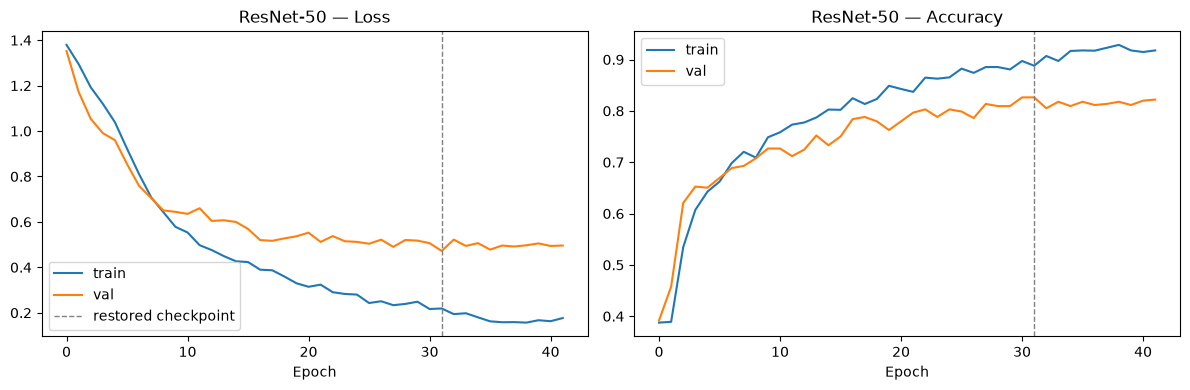

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.722


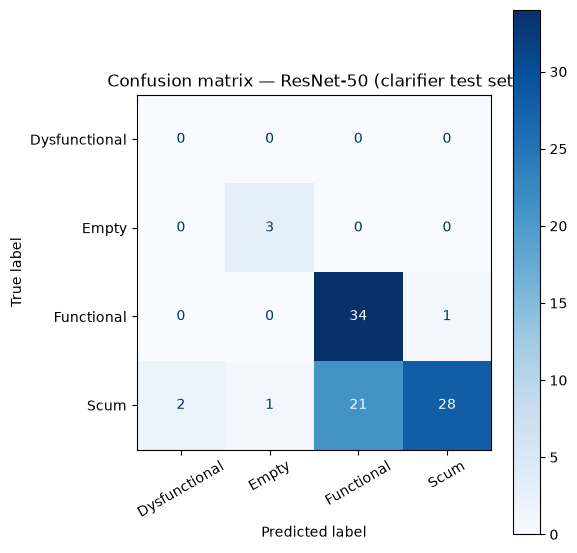

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000         0
        Empty      0.750     1.000     0.857         3
   Functional      0.618     0.971     0.756        35
         Scum      0.966     0.538     0.691        52

     accuracy                          0.722        90
    macro avg      0.583     0.627     0.576        90
 weighted avg      0.823     0.722     0.722        90

  [warn] 'Dysfunctional' has 0 examples in this test set — AUC undefined, skipping.


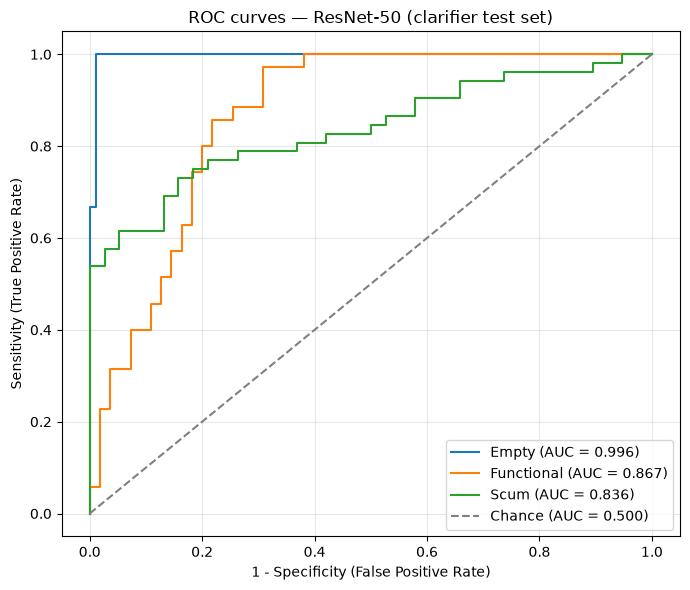

AUC (area under ROC curve) per class:
  Dysfunctional  : undefined (0 examples)
  Empty          : 0.996
  Functional     : 0.867
  Scum           : 0.836

Mean AUC (over 3/4 classes with test examples): 0.900


(np.float64(0.7222222222222222),
 {'Dysfunctional': nan,
  'Empty': 0.9961685823754789,
  'Functional': 0.867012987012987,
  'Scum': 0.8360323886639676})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/results_clarifier_resnet50_Atlantis.pkl


Saved model weights to ../models/clarifier_resnet50_cnn.pt
